In [1]:
import pandas as pd
import numpy
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\dell\Downloads\-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df["TotalCharges"]=df["TotalCharges"].replace(" ",0)
df["TotalCharges"]=df["TotalCharges"].astype("float")

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [14]:
df["customerID"].duplicated().sum()

np.int64(0)

In [19]:
def conv(value):
    if value == 1:
        return "yes"
    else:
        return "No"

df["SeniorCitizen"] = df["SeniorCitizen"].apply(conv)     
    


In [20]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


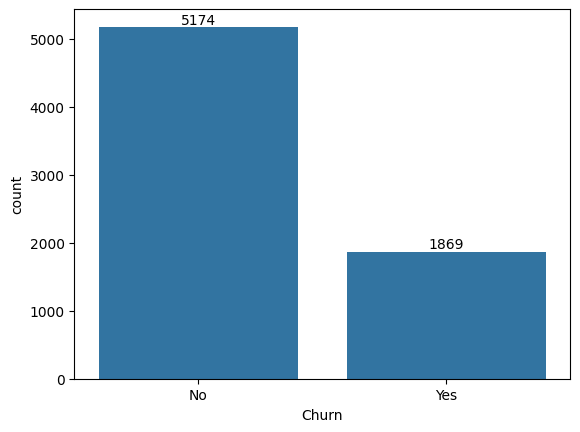

In [24]:
ax = sns.countplot(x="Churn",data=df)
ax.bar_label(ax.containers[0])
plt.show()

       Churn
Churn       
No      5174
Yes     1869


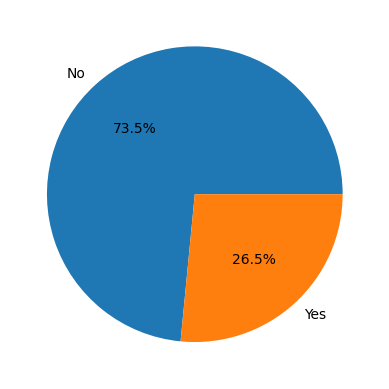

In [29]:
gb = df.groupby("Churn").agg({"Churn":"count"})
print(gb)
plt.pie(gb["Churn"], labels=gb.index, autopct="%1.1f%%")
plt.show()

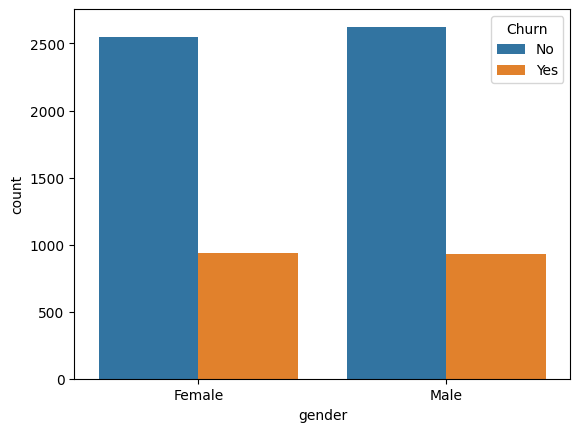

In [34]:
sns.countplot(x="gender",data=df, hue="Churn")
plt.show()

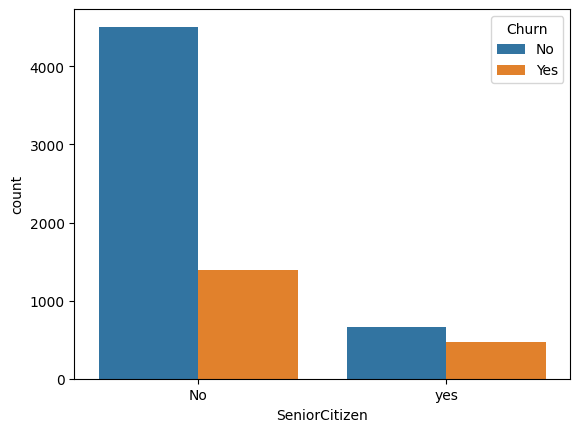

In [35]:
sns.countplot(x="SeniorCitizen",data=df, hue="Churn")
plt.show()

Churn                 No        Yes
SeniorCitizen                      
No             76.393832  23.606168
yes            58.318739  41.681261


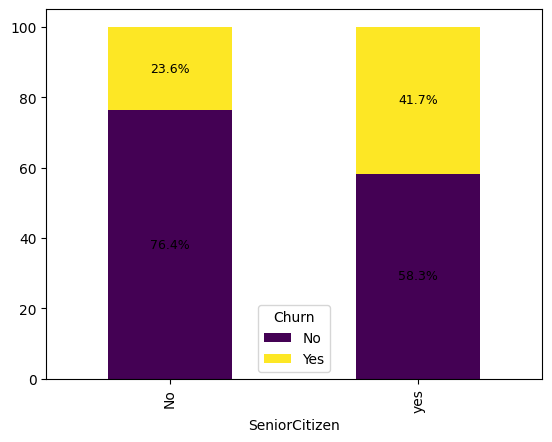

In [38]:
import pandas as pd

# count and convert to percentage
ct = pd.crosstab(df["SeniorCitizen"], df["Churn"])
ct_percent = ct.div(ct.sum(axis=1), axis=0) * 100

print(ct_percent)

ax = ct_percent.plot(kind="bar", stacked=True, colormap="viridis")

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2,
                p.get_y() + height/2,
                f'{height:.1f}%',
                ha='center', va='center', fontsize=9)

plt.show()

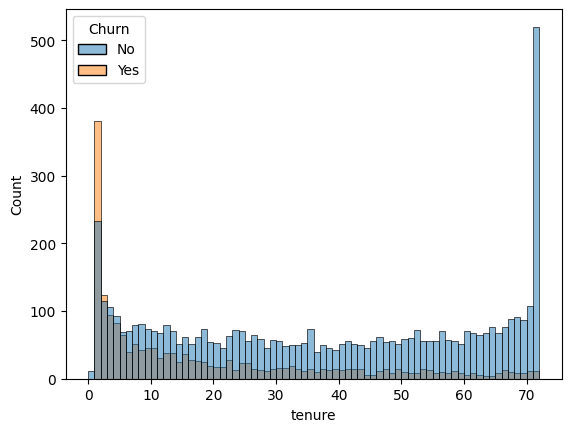

In [43]:
sns.histplot(x= "tenure",data=df, bins=72, hue="Churn")
plt.show()

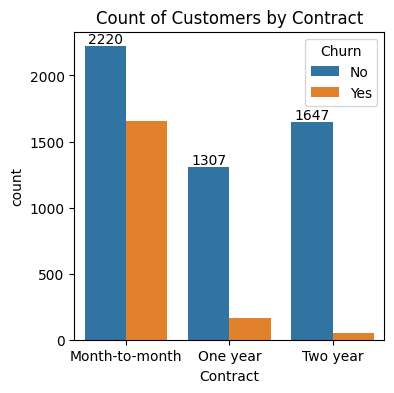

In [45]:
plt.figure(figsize=(4,4))
ax = sns.countplot(x="Contract",data=df, hue="Churn")
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Contract")
plt.show()

In [46]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

In [47]:
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

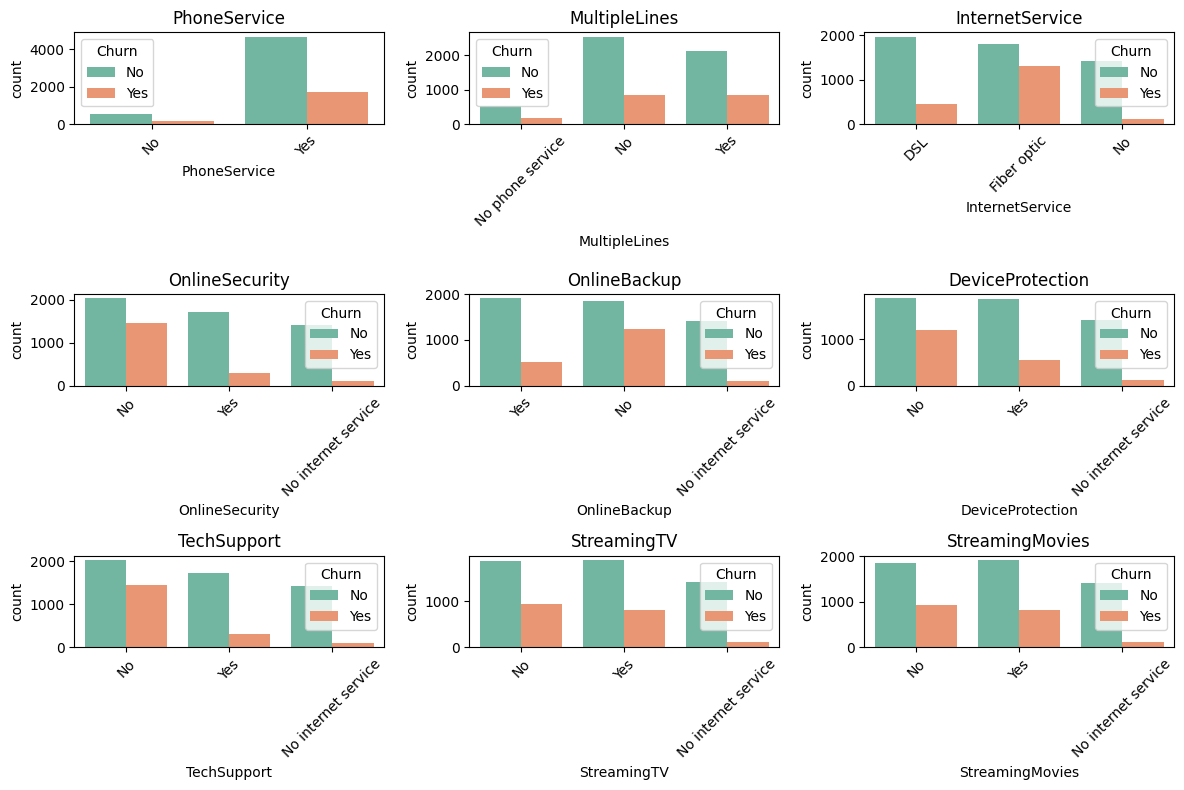

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 3, i)  # 3 rows, 3 columns
    sns.countplot(x=col, data=df, palette="Set2", hue= df["Churn"])
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

6. Key Business Insight
Customers generally adopt core telecom services first (phone + internet).
Value-added services (security, backup, tech support) have lower adoption.
There is a clear opportunity for:
bundling services
improving adoption of premium add-ons
targeting users with no security/support services (potential churn risk group)

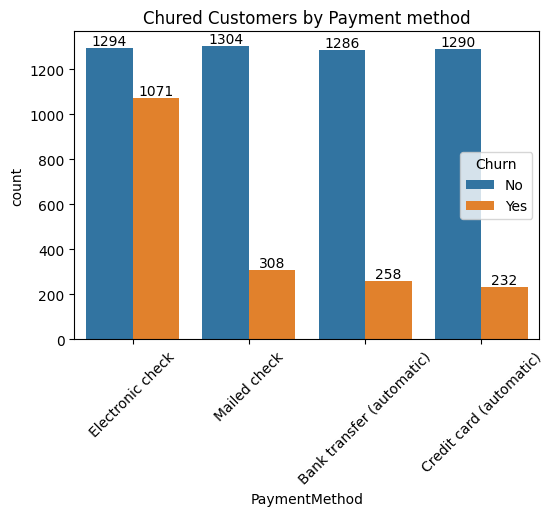

In [57]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x="PaymentMethod",data=df, hue="Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Chured Customers by Payment method")
plt.xticks(rotation=45)
plt.show()

Executive Summary (Dashboard Insights)
🧾 Customer Service Usage Overview
Core services like PhoneService and InternetService dominate usage
Many customers use basic telecom services but avoid premium add-ons
🌐 Internet & Streaming Behavior
Internet users are split between DSL, Fiber, and no service
Streaming services (TV & Movies) show moderate adoption
Indicates entertainment services are popular but not universal
🔐 Security & Protection Services (Critical Insight)
Low adoption of:
OnlineSecurity
TechSupport
DeviceProtection
OnlineBackup

👉 This is a key weak point in product penetration
👉 Customers are not strongly engaged with protection services

📞 Communication Services
Phone service is highly adopted (core dependency)
Multiple lines are not widely used → suggests optional upgrade behavior
🚨 Business Interpretation (Important)
Customers mostly stick to basic plans
Add-on services are underused → revenue expansion opportunity
Low engagement in security services may correlate with higher churn risk